# Thông tin kết nối google drive và extract tập dữ liệu

## Kết nối dữ liệu với google drive

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Extract file rar

In [ ]:
# !apt-get install unrar
# new_rar_path = '/content/drive/MyDrive/CS321_CV/HoaVietNam.rar'
# dis_extract_rar_path = '/content/drive/MyDrive/CS321_CV/Data'
# !unrar x $new_rar_path dis_extract_rar_path


# 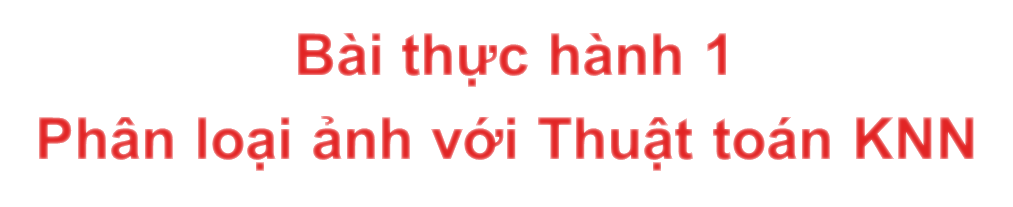

# 1. Mô tả

Cho trước 1 tập dữ liệu HoaVietNam chứa 05 loài hoa:
- Cuc: Tên loài hoa Cúc
- Dao: Tên loài hoa Đào
- Lan: Tên loài hoa Phong lan
- Mai: Tên loài hoa Mai
- Tho: Tên loài hoa Vạn thọ

Được tổ chức như sau:
- train: chứa 05 thư mục tương vơi 05 loài hoa, mỗi thư mục có 30 ảnh *.jpg
- test: chứa 05 thư mục tương vơi 05 loài hoa, mỗi thư mục có 10 ảnh *.jpg


# 2. Yêu cầu

- Mỗi ảnh sẽ được biểu diễn bằng vector đặc trưng dựa trên Histogram cho ảnh màu.
- Hãy áp dụng Bộ phân lớp KNeighborsClassifier với giá trị k=7 ( Từ thư viện: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html ) để xác định giá trị cho Độ chính xác cao nhất của hai tham số sau:

•	weights: {‘uniform’, ‘distance’}

•	metric: {

    •	braycurtis: Compute the Bray-Curtis distance between two 1-D arrays.

    •	canberra: Compute the Canberra distance between two 1-D arrays.

    •	correlation: Compute the correlation distance between two 1-D arrays.

    •	cosine: Compute the Cosine distance between 1-D arrays.

    •	euclidean: Computes the Euclidean distance between two 1-D arrays.

    •	minkowski: Compute the Minkowski distance between two 1-D arrays.
}



# Bài làm

## 1) Khai báo thư viên

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder


## 2) Đường dẫn tập dữ liệu

In [3]:
# root_dir = '/content/drive/MyDrive/CS231_CV/Data'
root_dir = '../Data'
train_dir = os.path.join(root_dir, 'HoaVietNam', 'train')
test_dir = os.path.join(root_dir, 'HoaVietNam', 'test')


## 3) Hàm trích xuất đặc trưng Histogram với kênh màu RGB

In [17]:
def extract_color_histogram_RGB(img_path, bins=256):
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # BRG -> RGB

    feature_vector = []
    
    for i in range(3):
        hist = cv2.calcHist([img], [i], None, [bins], [0, 256])
        hist = cv2.normalize(hist, hist).flatten() # Chuẩn hóa và làm phẳng
        feature_vector.extend(hist)

    feature_vector = np.array(feature_vector)
    feature_vector = cv2.normalize(feature_vector, feature_vector).flatten()

    return feature_vector # Kích thước: 256 * 3 = 768


## 4) Hàm lấy đặc trưng và nhãn kết hợp với hàm con trỏ trích xuất đặc trưng

In [18]:
def load_features_and_labels(root_dir, extract_feature_funct):
    images = []
    labels = []
    class_names = sorted(os.listdir(root_dir))

    for class_name in class_names:
        class_name_dir_path = os.path.join(root_dir, class_name)

        if os.path.isdir(class_name_dir_path):
            for img_file in os.listdir(class_name_dir_path): # Duyệt qua từng tệp trong thư mục
                img_path = os.path.join(class_name_dir_path, img_file)

                if img_file.endswith('.jpg'):
                    feature = extract_feature_funct(img_path)

                    if feature is not None:
                        images.append(feature)
                        labels.append(class_name)

    return np.array(images), np.array(labels)


## 5) Load dataset với trích xuất đặc trưng histogram và kênh màu RGB

In [19]:
X_train_rgb, y_train_rgb = load_features_and_labels(train_dir, extract_color_histogram_RGB)
X_test_rgb, y_test_rgb = load_features_and_labels(test_dir, extract_color_histogram_RGB)


In [20]:
print('X_train_rgb:', X_train_rgb.shape)
print('y_train_rgb:', y_train_rgb.shape)
print('X_test_rgb:', X_test_rgb.shape)
print('y_test_rgb:', y_test_rgb.shape)


X_train_rgb: (150, 768)
y_train_rgb: (150,)
X_test_rgb: (50, 768)
y_test_rgb: (50,)


## 6) Encode tập dữ liệu với trích xuất đặc trưng histogram

In [21]:
le = LabelEncoder()
le.fit(y_train_rgb)
y_train_rgb_encoded = le.transform(y_train_rgb)
y_test_rgb_encoded = le.transform(y_test_rgb)


In [22]:
print(y_train_rgb_encoded.shape)
print(y_test_rgb_encoded.shape)


(150,)
(50,)


## 7) Train và test

In [23]:
def train_knn(X_train, y_train, X_test, y_test, k , metric, weight):
    knn = KNeighborsClassifier(n_neighbors=k, metric=metric, weights=weight)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy, y_pred


In [24]:
def test(metrics, weights_options, X_train, y_train, X_test, y_test, best_accuracy=0, best_params={}, k=7):
    for metric in metrics:
        for weight in weights_options:
            accuracy, _ = train_knn(X_train, y_train, X_test, y_test, k, metric, weight)
            print(f"Accuracy with weight[{weight:>4}], metric[{metric}] = {accuracy:.2f}")

            if accuracy > best_accuracy:
                best_params = {'metric': metric, 'weight': weight}
                best_accuracy = accuracy

    return best_accuracy, best_params


## 8) Siêu tham số

In [25]:
k = 7
metrics = ['braycurtis', 'canberra', 'correlation', 'cosine', 'euclidean', 'minkowski']
weights_options = ['uniform', 'distance']
best_params = {}
best_accuracy = 0


## 9) Độ chính xác tốt nhất và tham số tối ưu khi trích xuất đặc trưng histogram với kênh màu RGB

In [26]:
best_accuracy_rgb, best_params_rgb = test(metrics, weights_options, X_train_rgb, y_train_rgb_encoded, X_test_rgb, y_test_rgb_encoded)


Accuracy with weight[uniform], metric[braycurtis] = 0.74
Accuracy with weight[distance], metric[braycurtis] = 0.78
Accuracy with weight[uniform], metric[canberra] = 0.72
Accuracy with weight[distance], metric[canberra] = 0.76
Accuracy with weight[uniform], metric[correlation] = 0.72
Accuracy with weight[distance], metric[correlation] = 0.70
Accuracy with weight[uniform], metric[cosine] = 0.74
Accuracy with weight[distance], metric[cosine] = 0.76
Accuracy with weight[uniform], metric[euclidean] = 0.74
Accuracy with weight[distance], metric[euclidean] = 0.76
Accuracy with weight[uniform], metric[minkowski] = 0.74
Accuracy with weight[distance], metric[minkowski] = 0.76


## 10) In kết quả tốt nhất với trích xuất đặc trưng histogram với kênh màu RGB

In [27]:
print(f"Best accuracy from histogram feature extraction with rgb color: {best_accuracy_rgb:.2f}")
print(f"Best parameters from histogram feature extraction with rgb color: {best_params_rgb}")


Best accuracy from histogram feature extraction with rgb color: 0.78
Best parameters from histogram feature extraction with rgb color: {'metric': 'braycurtis', 'weight': 'distance'}


# 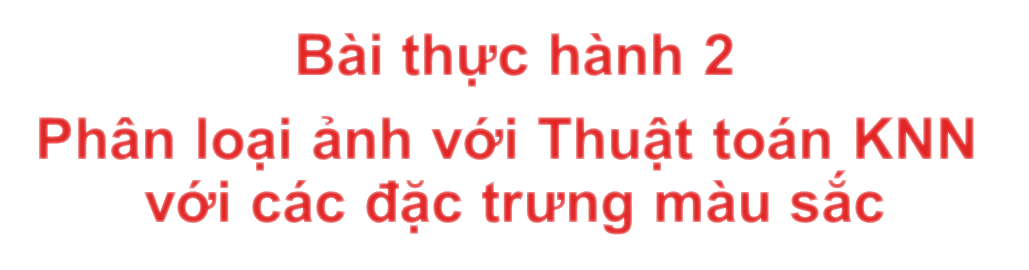

# 1. Mô tả

Sinh viên thưc hiện tiếp nội dung Bài tập 1 theo những yêu cầu của Bài tập 2

# Yêu cầu 1

## Sau khi thực hiện yêu cầu với đặc trưng Histogram (có thể dung RGB hoặc HSV), sinh viên đã chọn được tham số tốt nhất. Với tham số này, sinh viên rút trích 2 đặc trưng ảnh theo Moment màu và Màu chủ đạo trong ảnh. Cho biết độ chính xác phân loại khi sử dụng 2 đặc trưng này

# Bài làm yêu cầu 1

### Tham số tốt nhất của trích xuất đặc trưng histogram với kênh màu RGB

In [28]:
print(f"Best accuracy from histogram feature extraction with rgb color: {best_accuracy_rgb:.2f}")
print(f"Best parameters from histogram feature extraction with rgb color: {best_params_rgb}")


Best accuracy from histogram feature extraction with rgb color: 0.78
Best parameters from histogram feature extraction with rgb color: {'metric': 'braycurtis', 'weight': 'distance'}


## 1) Hàm trích xuất đặc trưng moment màu theo kênh màu RGB

In [29]:
def extract_color_moments(img_path):
    # Tính toán kênh màu (mean, variance, skewness) trên kênh RGB
    img = cv2.imread(img_path)
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mean = np.mean(rgb, axis=(0, 1))
    std = np.std(rgb, axis=(0, 1))
    skewness = np.mean(((rgb - mean) / (std + 1e-6)) ** 3, axis=(0, 1))
    return np.concatenate([mean, std, skewness])


## 2) Trích xuất đặc trưng momet với kênh màu RGB theo tham số tối ưu của đặc trưng histogram

In [30]:
X_train_moment, y_train_moment = load_features_and_labels(train_dir, extract_color_moments)
X_test_moment, y_test_moment = load_features_and_labels(test_dir, extract_color_moments)


In [31]:
print(X_train_moment.shape)
print(X_test_moment.shape)


(150, 9)
(50, 9)


## 3) Encode trích xuất đặc trưng moment với kênh màu RGB theo tham số tối ưu của trích xuất đặc trưng histogram

In [32]:
le = LabelEncoder()
le.fit(y_train_moment)
y_train_moment_encoded = le.transform(y_train_moment)
y_test_moment_encoded = le.transform(y_test_moment)


## 4) In kết quả tốt nhất của trích xuất đặc trưng moment với kênh màu RGB theo tham số tối ưu của trích xuất đặc trưng histogram

In [33]:
accuracy_moment, _ = train_knn(X_train_moment, y_train_moment_encoded, X_test_moment, y_test_moment_encoded, k, metric=best_params_rgb['metric'], weight=best_params_rgb['weight'])
print(f"Best accuracy from moment feature extraction with rgb color: {accuracy_moment:.2f}")


Best accuracy from moment feature extraction with rgb color: 0.66


## 5) Hàm trích xuất đặc trưng màu chủ đạo (dominant) với kênh màu RGB

In [34]:
def extract_dominant_color(img_path, k=3):
    # Rút trích bằng K-means clustering
    img = cv2.imread(img_path)
    pixels = img.reshape(-1, 3)
    pixels = np.float32(pixels)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
    kmeans = cv2.KMEANS_RANDOM_CENTERS

    _, labels, centers, = cv2.kmeans(pixels, k, None, criteria, 10, kmeans)
    hist = np.bincount(labels.flatten(), minlength=k) / labels.size
    centers = np.uint8(centers)
    return np.hstack([centers.flatten(), hist])


## 6) Trích xuất đặc trưng màu chủ đạo chính (dominant) với kênh màu RGB theo tham số tối ưu của trích xuất đặc trưng histogram

In [35]:
X_train_dominant, y_train_dominant = load_features_and_labels(train_dir, extract_feature_funct=extract_dominant_color)
X_test_dominant, y_test_dominant = load_features_and_labels(test_dir, extract_feature_funct=extract_dominant_color)


## 7) Encode trích xuất đặc trưng màu chủ đạo (dominant) với kênh màu RGB theo tham số tối ưu của trích xuất đặc trưng histogram

In [36]:
le = LabelEncoder()
le.fit(y_train_dominant)
y_train_dominant_encoded = le.transform(y_train_dominant)
y_test_dominant_encoded = le.transform(y_test_dominant)


## 8) In kết quả tốt nhất với trích xuất đặc trưng màu chủ đạo chính (dominant) với kênh màu RGB theo tham số tối ưu của trích xuất đặc trưng histogram

In [37]:
accuracy_dominant, _ = train_knn(X_train_dominant, y_train_dominant_encoded, X_test_dominant, y_test_dominant_encoded, k, metric=best_params_rgb['metric'], weight=best_params_rgb['weight'])
print(f"Best accuracy from dominant feature extraction with rgb color: {accuracy_dominant:.2f}")


Best accuracy from dominant feature extraction with rgb color: 0.64


# Yêu cầu 2

## Trích xuất đặc trưng Histogram trên hệ màu HSV với số bin tương ứng là 16 x 16 x 16
- So với kết quả trong bài 1, kết quả khi sử dụng đặc trưng này sẽ có kết quả khác.
- Yêu cầu 2.1: sinh viên hãy hiển thị những ảnh mà trong bài tập 1 chưa được phân loại đúng, nhưng khi sử dụng đặc trung này thi mô hình phân loai đúng'
- Yêu câu 2.2: sinh viên hãy hiển thị những ảnh trong tâp test mà mô hình sử dụng đặc trưng nay còn phân loại sai

# Bài làm yêu cầu 2

## Yêu cầu 2.0:

- theo tham số tối ưu của trích xuất đặc trưng histogram

## Bài làm yêu cầu 2.0

### 1) Trích xuất đặc trưng Histogram trên hệ màu HSV với số bin tương ứng là 16 x 16 x 16

In [38]:
def extract_color_histogram_HSV(img_path, bins=(16, 16, 16)):
    img = cv2.imread(img_path)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV) # BGR - > RGB

    feature_vector = []
    channels = [0, 1, 2]
    ranges = [0, 180, 0, 256, 0, 256]

    for i in range(3):
        hist = cv2.calcHist([img_hsv], channels, None, bins, ranges) # calchist(images, channels, mask, histSize, ranges)
        hist = cv2.normalize(hist, hist).flatten()
        feature_vector.extend(hist)

    feature_vector = np.array(feature_vector)
    feature_vector = cv2.normalize(feature_vector, feature_vector).flatten()

    return feature_vector # Kích thước: 16 * 3 = 48


### 2) Load đặc trưng và nhãn với trích xuất đặc trưng theo màu HSV

In [39]:
X_train_hsv, y_train_hsv = load_features_and_labels(train_dir, extract_feature_funct=extract_color_histogram_HSV)
X_test_hsv, y_test_hsv = load_features_and_labels(test_dir, extract_feature_funct=extract_color_histogram_HSV)


In [40]:
print(X_train_hsv.shape)
print(X_test_hsv.shape)


(150, 12288)
(50, 12288)


### 3) Encode HSV

In [15]:
le = LabelEncoder()
le.fit(y_train_hsv)
y_train_hsv_encoded = le.transform(y_train_hsv)
y_test_hsv_encoded = le.transform(y_test_hsv)


### 4) Best accuracy and best_parameters of feature extraction with HSV color

In [41]:
# best_accuracy_hsv, best_params_hsv = test(metrics, weights_options, X_train_hsv, y_train_hsv_encoded, X_test_hsv, y_test_hsv_encoded)
best_accuracy_hsv, _ = train_knn(X_train_hsv, y_train_hsv_encoded, X_test_hsv, y_test_hsv_encoded, k, best_params_rgb['metric'], best_params_rgb['weight'])


### 5) So sánh kết quả với Bài 1

In [42]:
print(f"Best accuracy from histogram feature extraction with rgb color: {best_accuracy_rgb:.2f}")
print(f"Best parameters from histogram feature extraction with rgb color: {best_params_rgb}")


Best accuracy from histogram feature extraction with rgb color: 0.78
Best parameters from histogram feature extraction with rgb color: {'metric': 'braycurtis', 'weight': 'distance'}


In [43]:
print(f"Best accuracy from histogram feature extraction with HSV color: {best_accuracy_hsv:.2f}")


Best accuracy from histogram feature extraction with HSV color: 0.88


## Yêu cầu 2.1:

- sinh viên hãy hiển thị những ảnh mà trong bài tập 1 chưa được phân loại đúng, nhưng khi sử dụng đặc trựng này (màu HSV) thi mô hình phân loai đúng

## Bài làm yêu cầu 2.1

### 1) Hàm Hiển thị ảnh với thông tin phân loại theo kênh màu

In [44]:
def display_images_with_classification(img, true_label, pred_wrong, pred_true, img_name, class_names):
    # Lấy tên lớp từ nhãn
    true_label_name = class_names[true_label]
    pred_wrong_name = class_names[pred_wrong]
    pred_true_name = class_names[pred_true]

    # Tạo tiêu đề ảnh RGB (sai) - ảnh HSV (đúng)
    rgb_title = f"[RGB]\nPredict: {pred_wrong_name}\nGroundtruth: {true_label_name}"
    hsv_title = f"[HSV]\nPredict: {pred_true_name}\nGroundtruth: {true_label_name}"

    # Tạo figure với 2 subplot
    img_test = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

    # Thêm tiêu đề cho subplot
    # RGB
    ax1.imshow(img_test)
    ax1.set_title(rgb_title, fontsize=10)
    ax1.axis('off')

    # HSV
    ax2.imshow(img_test)
    ax2.set_title(hsv_title, fontsize=10)
    ax2.axis('off')

    # Tạo tiêu đều và hiển thị ảnh test
    fig.suptitle(f"Picture: {img_name}", fontsize=12)
    plt.tight_layout()
    plt.show()


### 2) Hàm lọc và hiển thị các ảnh thỏa mãn điều kiện kênh màu RGB phân loại sai - kênh màu HSV phân loại đúng

In [45]:
def compare_images_classified_correctly_with_HSV_not_with_RGB(y_test_encoded, y_pred_rgb, y_pred_hsv, img_paths, class_names):
    for i in range(len(y_test_encoded)):
        if y_pred_rgb[i] != y_test_encoded[i] and y_pred_hsv[i] == y_test_encoded[i]:
            img = cv2.imread(img_paths[i])

            # Lấy tên thư mục con và tạo tên hiển thị
            folder_name = os.path.basename(os.path.dirname(img_paths[i]))
            img_name = f"{folder_name} - Image {i + 1}"

            # Hiển thị so sánh dự đoán RGB sai và HSV đúng
            display_images_with_classification(img, y_test_encoded[i], y_pred_rgb[i], y_pred_hsv[i], img_name, class_names)


### 3) Hàm lấy đuờng dẫn tập ảnh test và danh sách tên các loài hoa

In [46]:
def get_image_paths(img_dir, file_extenstion='.jpg'):
    img_paths = []
    class_name = []

    for label_name in os.listdir(img_dir): # Duyệt qua từng thư mục con
        label_path = os.path.join(img_dir, label_name)

        if os.path.isdir(label_path): # Kiểm tra nếu label_name là thư mục con
            class_name.append(label_name)
            for img_name in os.listdir(label_path):
                img_path = os.path.join(label_path, img_name)

                if (img_name.endswith(file_extenstion)):
                    img_paths.append(img_path)

    return img_paths, class_name


### 4) Dự đoán với y_pred_rgb, y_pred_hsv

In [48]:
_, y_pred_rgb = train_knn(X_train_rgb, y_train_rgb_encoded, X_test_rgb, y_test_rgb_encoded, k, best_params_rgb['metric'], best_params_rgb['weight'])
_, y_pred_hsv = train_knn(X_train_hsv, y_train_hsv_encoded, X_test_hsv, y_test_hsv_encoded, k, best_params_rgb['metric'], best_params_rgb['weight'])


In [49]:
print('y_pred_rgb:',y_pred_rgb, y_pred_rgb.shape, sep='\n')
print()
print('y_pred_hsv:',y_pred_hsv, y_pred_hsv.shape, sep='\n')


y_pred_rgb:
[1 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 3 1 1 1 2 1 1 2 3 1 2 2 2 0 3 3 3 3 4 3 3
 3 4 4 4 4 4 4 4 4 4 4 3 4]
(50,)

y_pred_hsv:
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 1 2 2 1 2 3 2 2 2 2 0 3 3 3 3 3 4 3
 3 3 3 4 4 3 4 4 4 4 4 4 4]
(50,)


### 5) So sánh kết quả trích xuất đặc trưng theo kênh màu RGB và kênh màu HSV

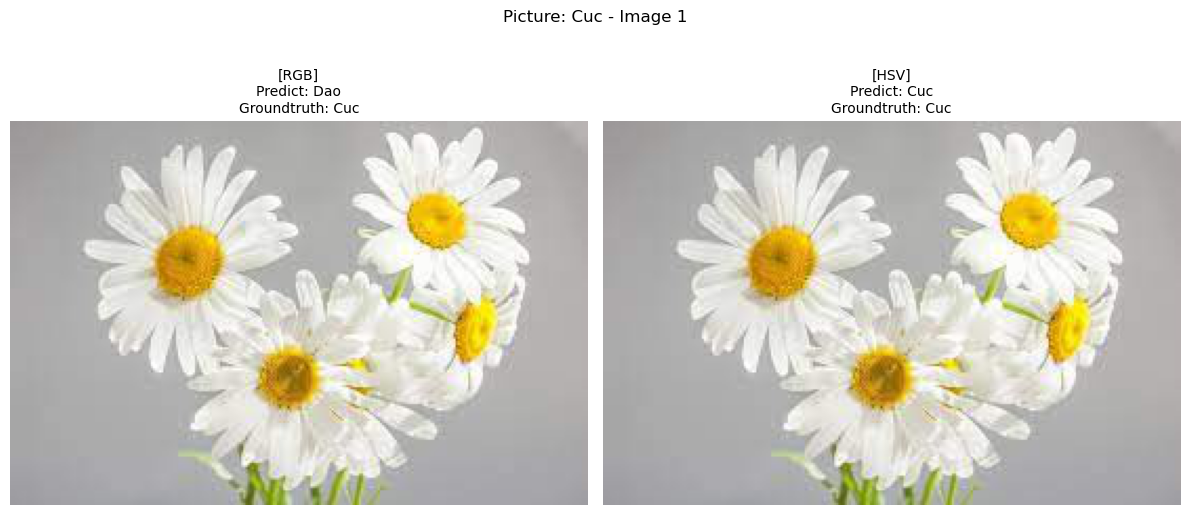

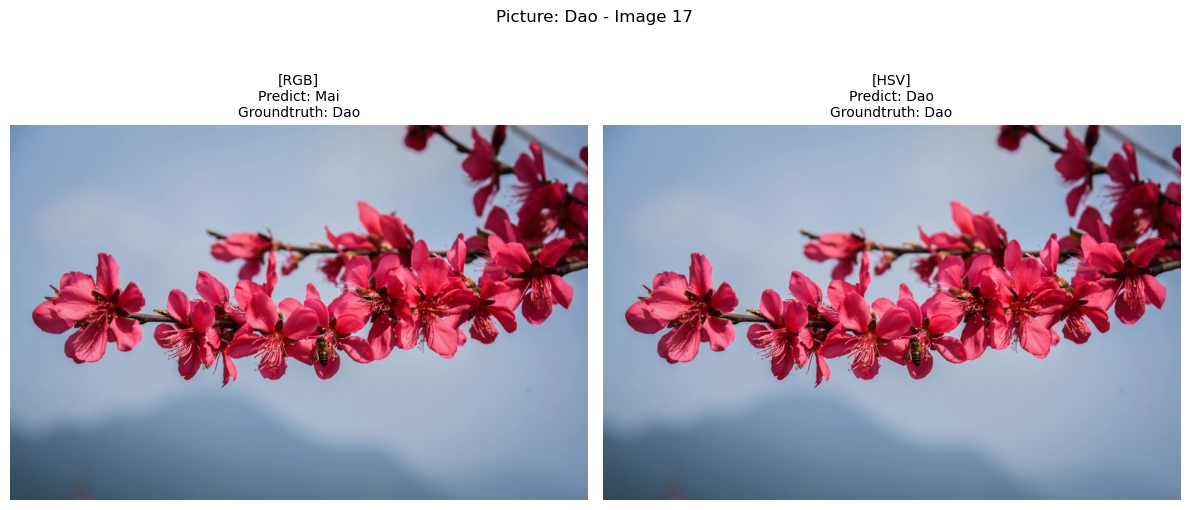

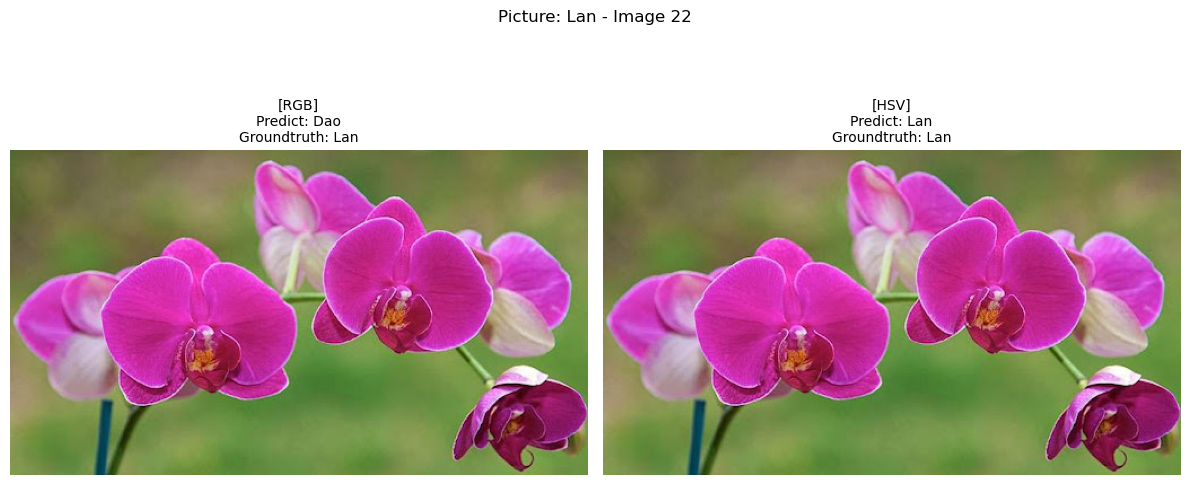

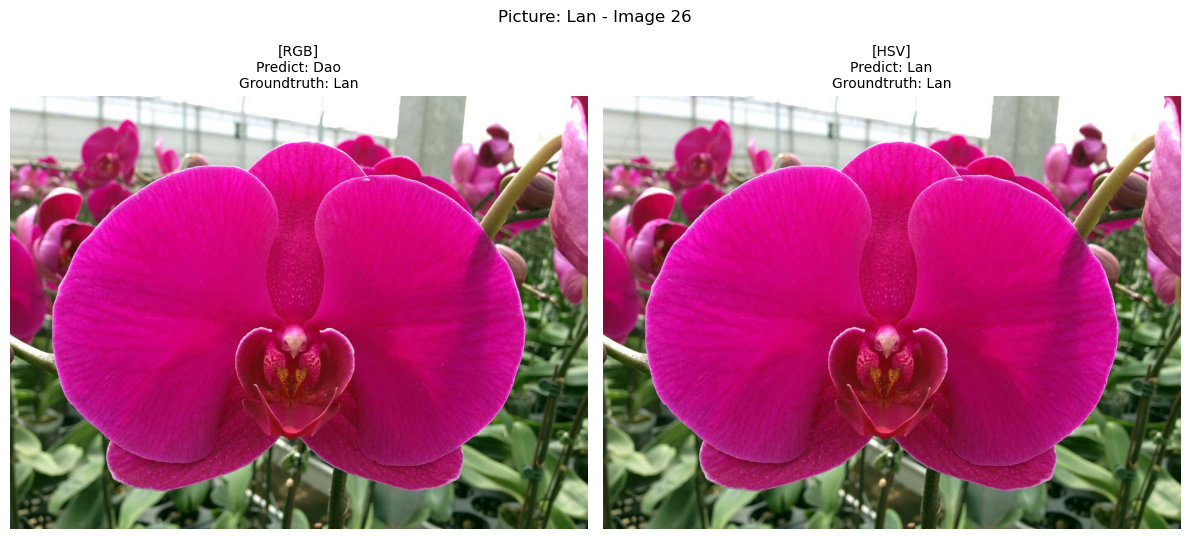

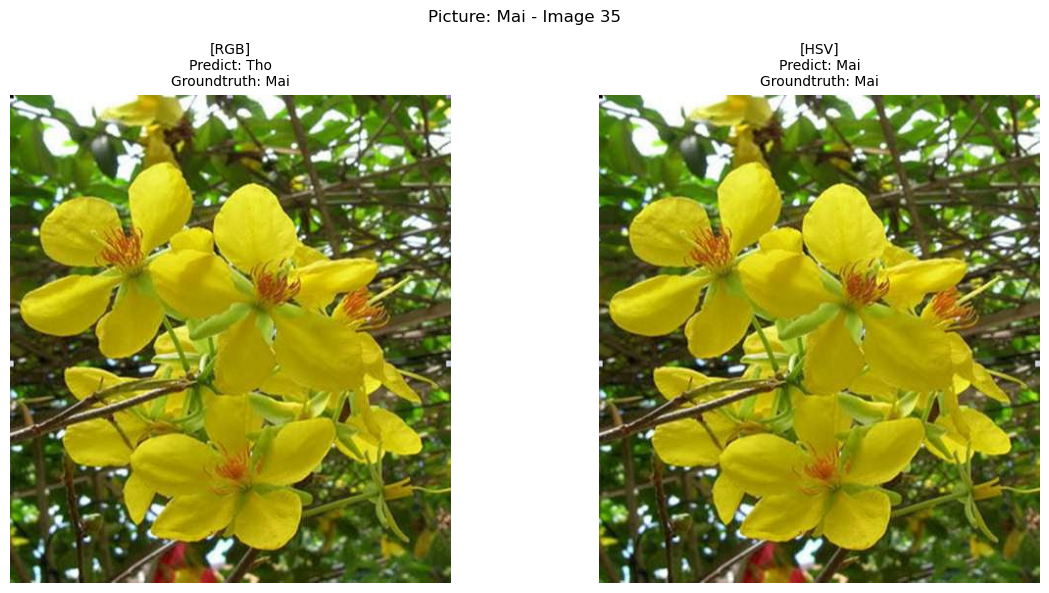

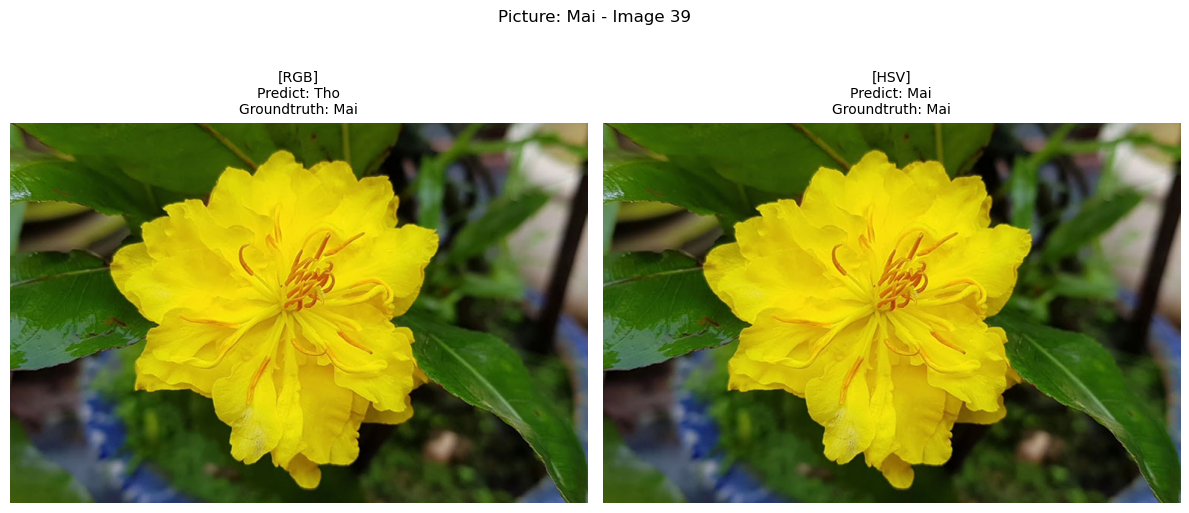

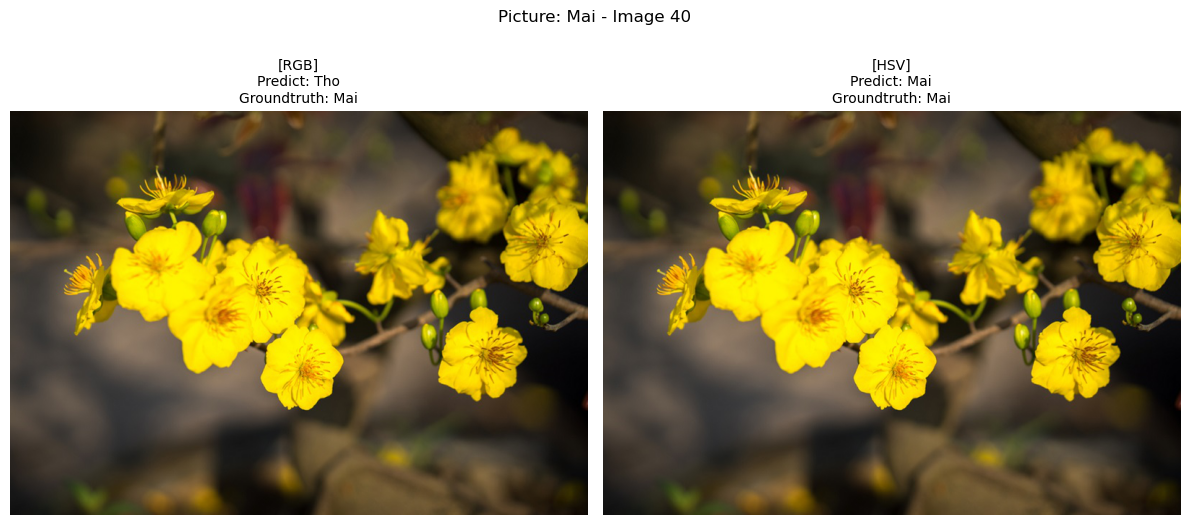

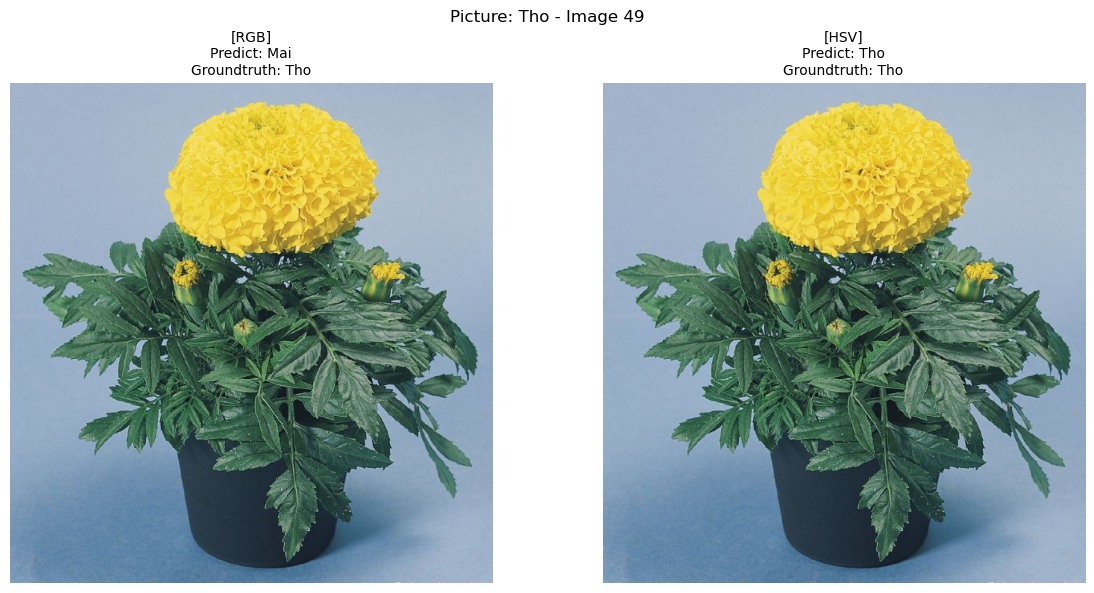

In [50]:
y_test_encoded = y_test_rgb_encoded # Hoặc y_test_hsv_encoded là giông nhau vì cùng tập ảnh và nhãn sẽ không thay đổi, khác mỗi vetor đặc trưng

test_images_paths, class_names = get_image_paths(test_dir)
compare_images_classified_correctly_with_HSV_not_with_RGB(y_test_encoded, y_pred_rgb, y_pred_hsv, test_images_paths, class_names)


## Yêu cầu 2.2:

- sinh viên hãy hiển thị những ảnh trong tâp test mà mô hình sử dụng đặc trưng nay (kênh màu HSV) còn phân loại sai

## Bài làm yêu cầu 2.2

### 1) Hàm hiển thị ảnh với thông tin phân loại trích xuất đặc trưng histogram với 1 kênh màu - HSV

In [51]:
def display_images_with_classification(img, true_label, pred, img_name, class_names, feature_color=''):
    # Lấy tên lớp từ nhãn
    groundtruth_name = class_names[true_label]
    pred_name = class_names[pred]

    # Tạo tiêu đề ảnh RGB (sai) - ảnh HSV (đúng)
    pred_title = f"[{feature_color}] - Predict: {pred_name}\n Groundtruth: {groundtruth_name}"

    # Tạo figure với subplot với feature_color
    img_test = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 6))

    # Thêm tiêu đề cho subplot
    ax.imshow(img_test)
    ax.set_title(pred_title, fontsize=10)
    ax.axis('off')

    # Tạo tiêu đều và hiển thị ảnh test
    fig.suptitle(f"Picture: {img_name}", fontsize=12)
    plt.tight_layout()
    plt.show()


### 2) Hàm lọc và hiển thị các ảnh trích xuất đặc trưng có kênh màu HSV phân loại sai

In [52]:
def show_images_classified_incorrectly_with_HSV(y_test_encoded, y_pred, img_paths, class_names):
    for i in range(len(y_test_encoded)):
        if y_pred[i] != y_test_encoded[i]:
            img = cv2.imread(img_paths[i])

            # Lấy tên thư mục và tạo tên hiễn thị
            folder_name = os.path.basename(os.path.dirname(img_paths[i]))
            img_name = f"{folder_name} - Image {i + 1}"

            # Hiển thị phân loại sai
            display_images_with_classification(img, y_test_encoded[i], y_pred[i], img_name, class_names, feature_color='HSV')


### 3) Hiển thị những ảnh trích xuất đặc trưng histogram với kênh màu HSV phân loại sai

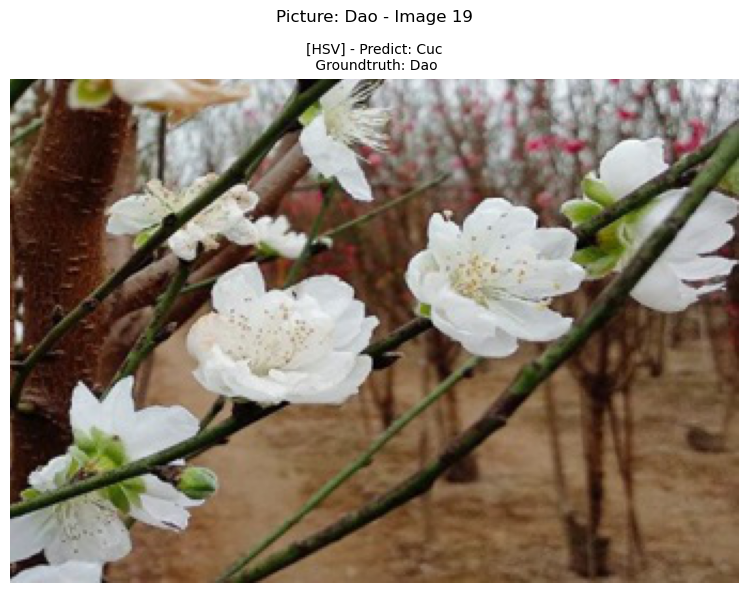

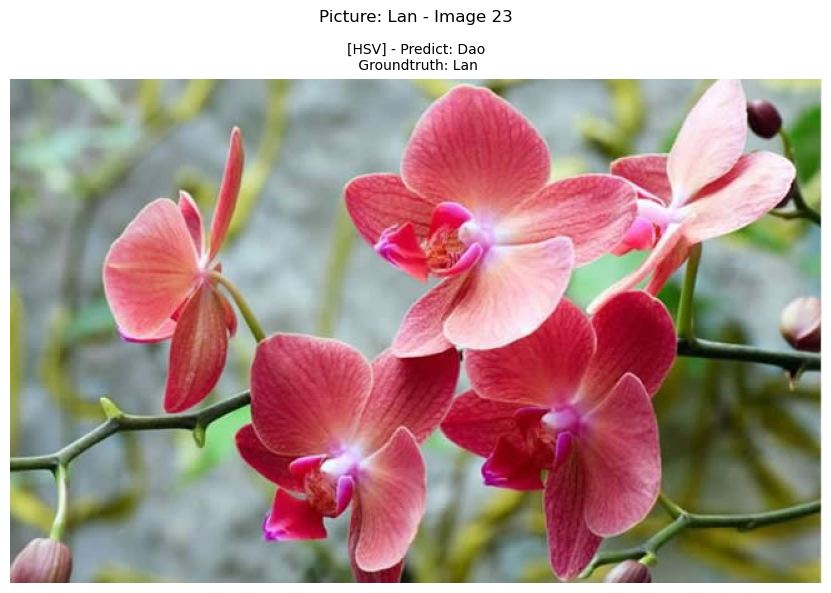

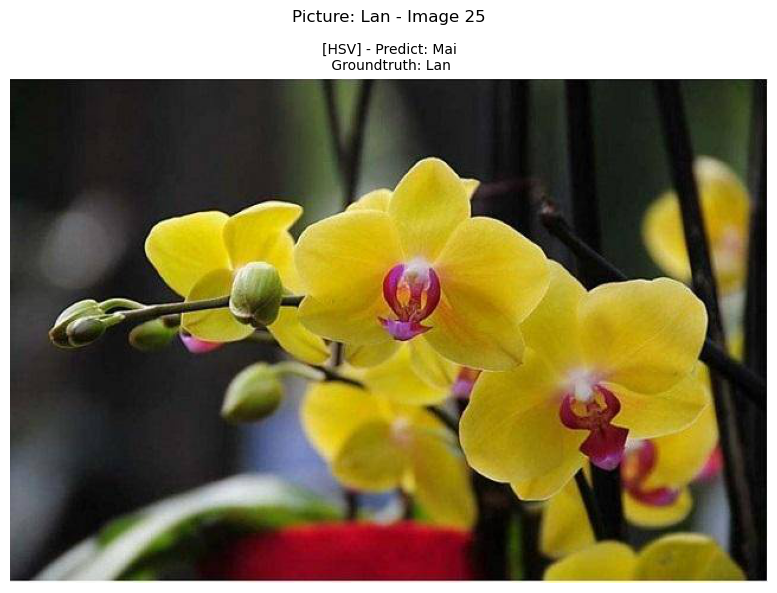

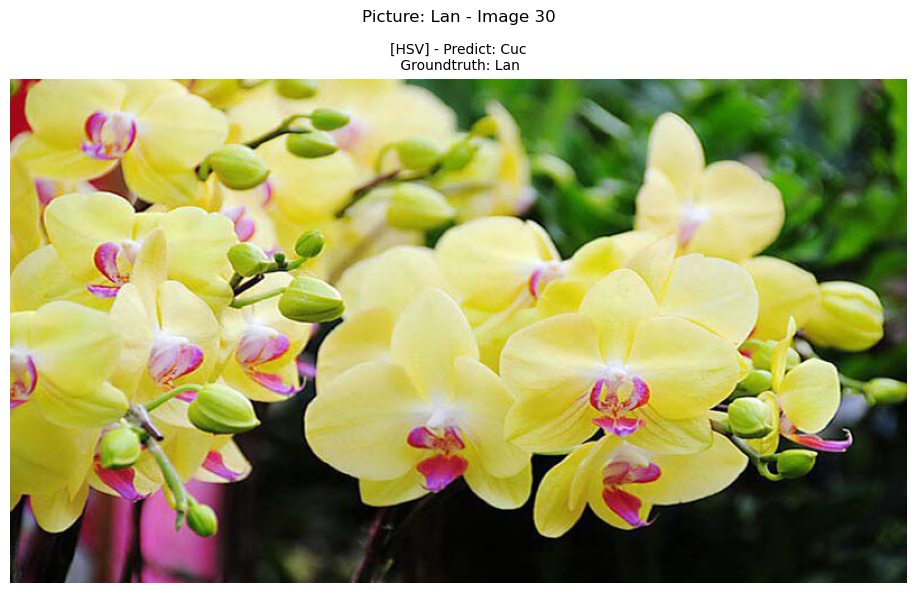

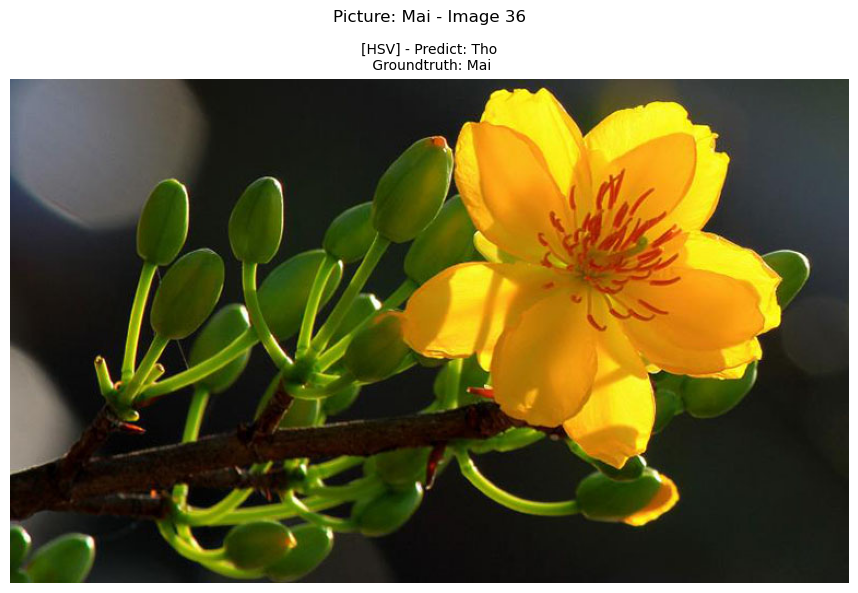

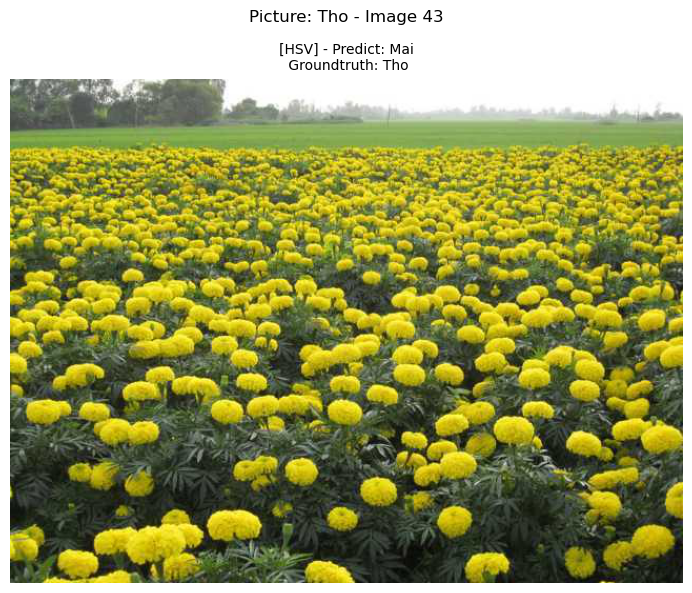

In [53]:
y_test_encoded = y_test_hsv_encoded

test_images_paths, class_names = get_image_paths(test_dir)
show_images_classified_incorrectly_with_HSV(y_test_encoded, y_pred_hsv, test_images_paths, class_names)


# 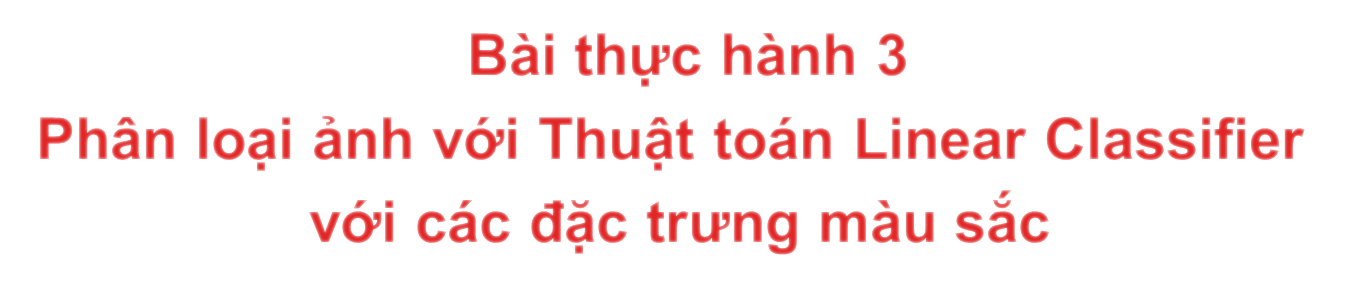

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score


In [55]:
X_train_hsv, y_train_hsv = load_features_and_labels(train_dir, extract_feature_funct=extract_color_histogram_HSV)
X_test_hsv, y_test_hsv = load_features_and_labels(test_dir, extract_feature_funct=extract_color_histogram_HSV)


In [ ]:
le = LabelEncoder()
le.fit(y_train_hsv)
y_train_hsv_encoded = le.transform(y_train_hsv)
y_test_hsv_encoded = le.transform(y_test_hsv)


# Param Grids

In [ ]:
param_grids = {
    'l1': {'penalty': ['l1'], 'solver': ['liblinear', 'saga']},
    'l2': {'penalty': ['l2'], 'solver': ['newton-cg', 'lbfgs', 'sag', 'saga']},
    'elasticnet': {'penalty': ['elasticnet'], 'solver': ['saga'], 'l1_ratio': [0.5]},
    'none': {'penalty': [None], 'solver': ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']}
}

# In ra các param_grid đã tạo từ điển param_grids
for penalty, param_grid in param_grids.items():
    print(f"param_grid for {penalty}: {param_grid}")


param_grid for l1: {'penalty': ['l1'], 'solver': ['liblinear', 'saga']}
param_grid for l2: {'penalty': ['l2'], 'solver': ['newton-cg', 'lbfgs', 'sag', 'saga']}
param_grid for elasticnet: {'penalty': ['elasticnet'], 'solver': ['saga'], 'l1_ratio': [0.5]}
param_grid for none: {'penalty': [None], 'solver': ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']}


# Model

In [62]:
clf = LogisticRegression(max_iter=100)
clf


LogisticRegression()

# GridSearch for Penalty function

In [78]:
def grid_search_penalty(X_train, y_train, X_test, y_test, param_grid, model, scoring = 'f1_macro', penalty=''):
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=5, n_jobs=1, verbose=1)
    grid_search.fit(X_train, y_train)
    
    result = grid_search.cv_results_
    for mean_f1, params in zip(result['mean_test_score'], result['params']):
        print(f"Params: {params} - Macro-F1: {mean_f1:.4f}" )
        
    print(f"Best score (Macro-F1): {grid_search.best_score_:.4f}")
    print(f"Best params (Macro-F1): {grid_search.best_params_}")
    
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test, )
    test_f1 = f1_score(y_test, y_pred, average='macro')
    print(f"Test F1-Score for {penalty}: {test_f1:.4f}")
    
    return [grid_search.best_score_, grid_search.best_params_]


# GridSearch for penalty ***l1***

In [79]:
best_l1 = grid_search_penalty(X_train_hsv, y_train_hsv_encoded, X_test_hsv, y_test_hsv_encoded, param_grids['l1'], model=clf, penalty='l1')


Fitting 5 folds for each of 2 candidates, totalling 10 fits
Params: {'penalty': 'l1', 'solver': 'liblinear'} - Macro-F1: 0.3852
Params: {'penalty': 'l1', 'solver': 'saga'} - Macro-F1: 0.3715
Best score (Macro-F1): 0.3852
Best params (Macro-F1): {'penalty': 'l1', 'solver': 'liblinear'}
Test F1-Score for l1: 0.4153


# GridSearch for penalty ***l2***

In [80]:
best_l2 = grid_search_penalty(X_train_hsv, y_train_hsv_encoded, X_test_hsv, y_test_hsv_encoded, param_grids['l2'], model=clf, penalty='l2')


Fitting 5 folds for each of 4 candidates, totalling 20 fits
Params: {'penalty': 'l2', 'solver': 'newton-cg'} - Macro-F1: 0.7861
Params: {'penalty': 'l2', 'solver': 'lbfgs'} - Macro-F1: 0.7861
Params: {'penalty': 'l2', 'solver': 'sag'} - Macro-F1: 0.7861
Params: {'penalty': 'l2', 'solver': 'saga'} - Macro-F1: 0.7861
Best score (Macro-F1): 0.7861
Best params (Macro-F1): {'penalty': 'l2', 'solver': 'newton-cg'}
Test F1-Score for l2: 0.8602


# GridSearch for penalty ***Elasticnet***

In [81]:
best_elasticnet = grid_search_penalty(X_train_hsv, y_train_hsv_encoded, X_test_hsv, y_test_hsv_encoded, param_grids['elasticnet'], model=clf, penalty='elasticnet')


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Params: {'l1_ratio': 0.5, 'penalty': 'elasticnet', 'solver': 'saga'} - Macro-F1: 0.4982
Best score (Macro-F1): 0.4982
Best params (Macro-F1): {'l1_ratio': 0.5, 'penalty': 'elasticnet', 'solver': 'saga'}
Test F1-Score for elasticnet: 0.6585


# GridSearch for penalty ***None***

In [82]:
best_none = grid_search_penalty(X_train_hsv, y_train_hsv_encoded, X_test_hsv, y_test_hsv_encoded, param_grids['none'], model=clf, penalty='none')


Fitting 5 folds for each of 6 candidates, totalling 30 fits


c:\Users\nhata\anaconda3\envs\ML_env\lib\site-packages\sklearn\linear_model\_glm\_newton_solver.py:576: LinAlgWarning: The inner solver of NewtonCholeskySolver stumbled upon a singular or very ill-conditioned Hessian matrix at iteration 1. It will now resort to lbfgs instead.
Further options are to use another solver or to avoid such situation in the first place. Possible remedies are removing collinear features of X or increasing the penalization strengths.
The original Linear Algebra message was:
Matrix is singular.
  warnings.warn(
c:\Users\nhata\anaconda3\envs\ML_env\lib\site-packages\sklearn\linear_model\_glm\_newton_solver.py:576: LinAlgWarning: The inner solver of NewtonCholeskySolver stumbled upon a singular or very ill-conditioned Hessian matrix at iteration 1. It will now resort to lbfgs instead.
Further options are to use another solver or to avoid such situation in the first place. Possible remedies are removing collinear features of X or increasing the penalization strengt

Params: {'penalty': None, 'solver': 'lbfgs'} - Macro-F1: 0.8040
Params: {'penalty': None, 'solver': 'liblinear'} - Macro-F1: nan
Params: {'penalty': None, 'solver': 'newton-cg'} - Macro-F1: 0.7985
Params: {'penalty': None, 'solver': 'newton-cholesky'} - Macro-F1: 0.8040
Params: {'penalty': None, 'solver': 'sag'} - Macro-F1: 0.7870
Params: {'penalty': None, 'solver': 'saga'} - Macro-F1: 0.8261
Best score (Macro-F1): 0.8261
Best params (Macro-F1): {'penalty': None, 'solver': 'saga'}
Test F1-Score for none: 0.8227


c:\Users\nhata\anaconda3\envs\ML_env\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


# Best parameters for model

In [ ]:
def find_best_model(*models):
    best_model = max(models, key=lambda x: x[0])

    print('Best model:')
    print(f'Best accuracy: {best_model[0]:.4f}')
    print(f"Params: {best_model[1]}")
    return best_model


In [87]:
best_model = find_best_model(best_l1, best_l2, best_elasticnet, best_none)



Best model:
Best accuracy: 0.8261
Params: {'penalty': None, 'solver': 'saga'}
